Step 1: Loading a Dataset

In [2]:
from sklearn.datasets import load_iris 
iris = load_iris() 

X = iris.data 
y = iris.target 
  
feature_names = iris.feature_names 
target_names = iris.target_names 
  
print("Feature names:", feature_names) 
print("Target names:", target_names) 

print("\nType of X is:", type(X)) 

print("\nFirst 5 rows of X:\n", X[:5])

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']

Type of X is: <class 'numpy.ndarray'>

First 5 rows of X:
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


Step 2: Splitting the Dataset

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=1)

In [8]:
print("X_train Shape:",  X_train.shape)
print("X_test Shape:", X_test.shape)
print("Y_train Shape:", y_train.shape)
print("Y_test Shape:", y_test.shape)

X_train Shape: (90, 4)
X_test Shape: (60, 4)
Y_train Shape: (90,)
Y_test Shape: (60,)


Step 3: Handling Categorical Data

LabelEncoder(): It is initialized to create an encoder object that will convert categorical values into numerical labels.

fit_transform(): This method first fits the encoder to the categorical data and then transforms the categories into corresponding numeric labels.

In [14]:
from sklearn.preprocessing import LabelEncoder

categorical_feature = ['cat', 'dog', 'dog', 'cat', 'bird']

encoder = LabelEncoder()

encoded_feature = encoder.fit_transform(categorical_feature)

print("Encoded feature:", encoded_feature)

Encoded feature: [1 2 2 1 0]


. One-Hot Encoding()

In [17]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

categorical_feature = ['cat', 'dog', 'dog', 'cat', 'bird']

categorical_feature = np.array(categorical_feature).reshape(-1, 1)

encoder = OneHotEncoder(sparse_output=False)

encoded_feature = encoder.fit_transform(categorical_feature)

print("OneHotEncoded feature:\n", encoded_feature)

OneHotEncoded feature:
 [[0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]]


Step 4: Training the Model

In [20]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=200)

Step 5: Make Predictions

In [23]:
y_pred = log_reg.predict(X_test)

Step 6: Evaluating Model Accuracy

In [26]:
from sklearn import metrics
print("Logistic Regression model accuracy:", metrics.accuracy_score(y_test, y_pred))

Logistic Regression model accuracy: 0.9666666666666667


In [28]:
sample = [[3, 5, 4, 2], [2, 3, 5, 4]]
preds = log_reg.predict(sample)
pred_species = [iris.target_names[p] for p in preds]
print("Predictions:", pred_species)

Predictions: ['virginica', 'virginica']


Working with new dataset

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report


import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [45]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [47]:
df.isna().sum().sum()

0

In [53]:
df.duplicated().sum()

0

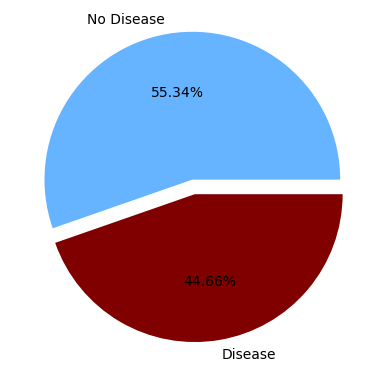

In [55]:
plt.pie(df['HeartDisease'].value_counts(),labels=['No Disease','Disease'],autopct='%1.2f%%', explode = [0.1,0],colors=['#66b3ff','maroon'])
plt.show()

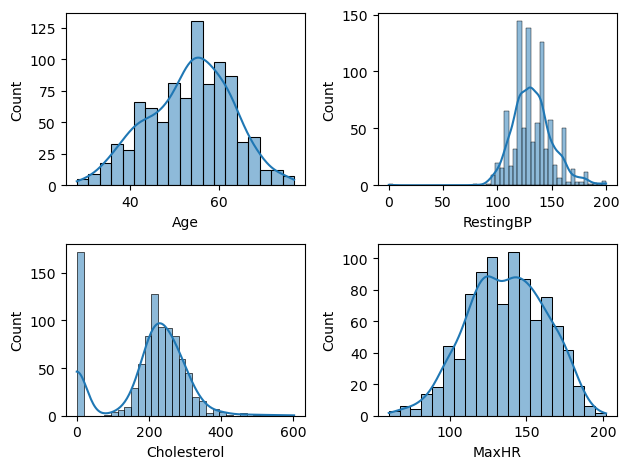

In [61]:
def plotting(var,num):
  plt.subplot(2,2,num)
  sns.histplot(df[var] , kde=True)
plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)
plt.tight_layout()

In [63]:
# Cholestrol can't be zero
ch_mean = df.loc[df['Cholesterol'] != 0, 'Cholesterol'].mean()
df['Cholesterol'].replace(0,ch_mean,inplace=True)

In [65]:
# Resting BP also can't be zero
rest_bp_mean = df.loc[df['RestingBP'] != 0, 'RestingBP'].mean()
df['RestingBP'].replace(0,rest_bp_mean,inplace=True)

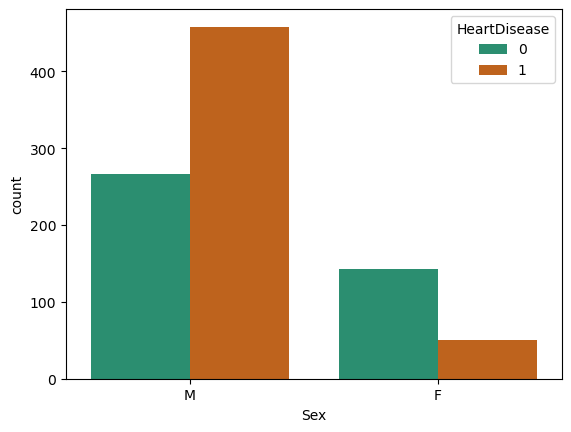

In [67]:
sns.countplot(x = df['Sex'] , hue=df['HeartDisease'] , palette='Dark2')
plt.show()